In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Configuración de reproducibilidad
np.random.seed(42)
n = 1000

# 1. EQUIPO ALFA: El estándar de simetría (Normal)
# Media y Mediana casi idénticas (~3000)
alfa = np.random.normal(loc=3000, scale=250, size=n)

# 2. EQUIPO BETA: Sesgo a la Derecha "Aesthetic" (Log-normal)
# Genera una curva suave con cola a la derecha. Media > Mediana.
beta_raw = np.random.lognormal(mean=0, sigma=0.5, size=n)
# Escalamos para que los datos vivan entre ~1500 y ~7000
beta = (beta_raw * 1200) + 1500

# 3. EQUIPO GAMMA: Sesgo a la Izquierda "Aesthetic" (Log-normal invertida)
# Reflejamos la log-normal para que la cola apunte a la izquierda. Media < Mediana.
gamma_raw = np.random.lognormal(mean=0, sigma=0.5, size=n)
# Al restar de un valor alto, invertimos la dirección del sesgo
gamma = 6500 - (gamma_raw * 1200)

# Crear el DataFrame final
df_final = pd.DataFrame({
    'Equipo_Alfa': alfa,
    'Equipo_Beta': beta,
    'Equipo_Gamma': gamma
})

# Mezclamos las filas para que no haya orden aparente
df_final = df_final.sample(frac=1).reset_index(drop=True)

# Guardar el archivo definitivo
df_final.to_csv('df_adicional_2.csv', index=False)

# --- VERIFICACIÓN DE LAS BRECHAS ---
resumen = pd.DataFrame({
    'Media': df_final.mean(),
    'Mediana': df_final.median(),
    'Diferencia (M-Me)': df_final.mean() - df_final.median(),
    'Sesgo (Skewness)': df_final.skew()
})
print(resumen.round(2))

                Media  Mediana  Diferencia (M-Me)  Sesgo (Skewness)
Equipo_Alfa   3004.83  3006.33              -1.49              0.12
Equipo_Beta   2906.43  2738.45             167.98              1.58
Equipo_Gamma  5139.64  5300.15            -160.51             -2.35


In [14]:
numerical_values = df_final.columns.to_list()
numerical_values

['Equipo_Alfa', 'Equipo_Beta', 'Equipo_Gamma']

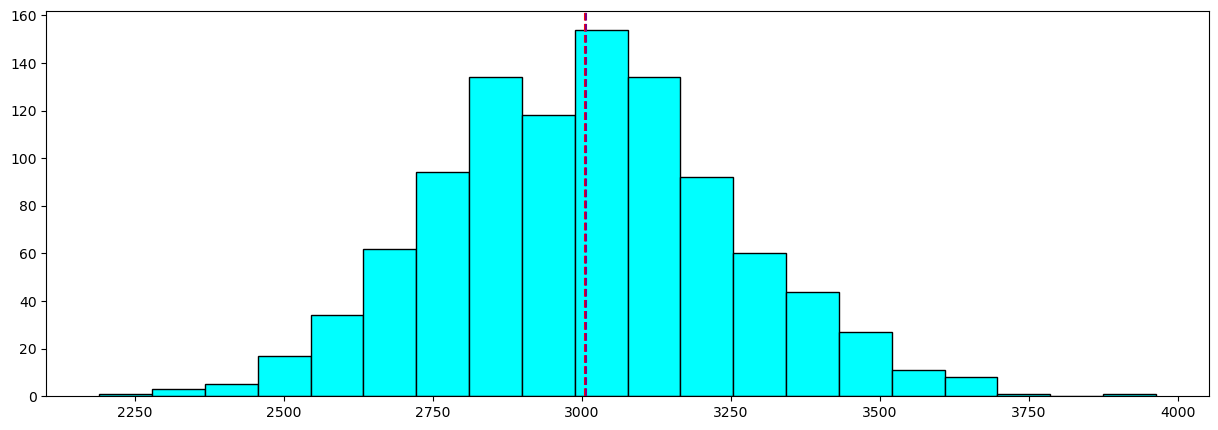

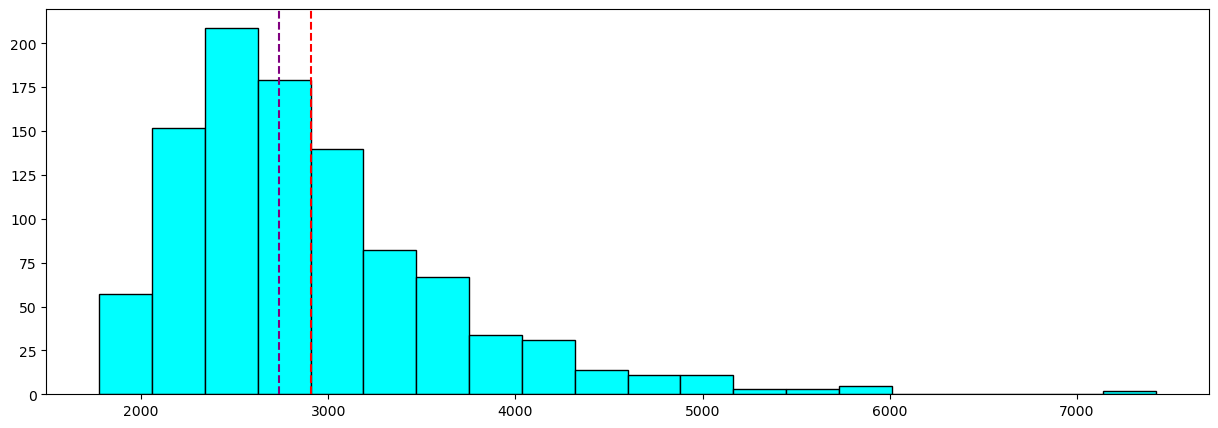

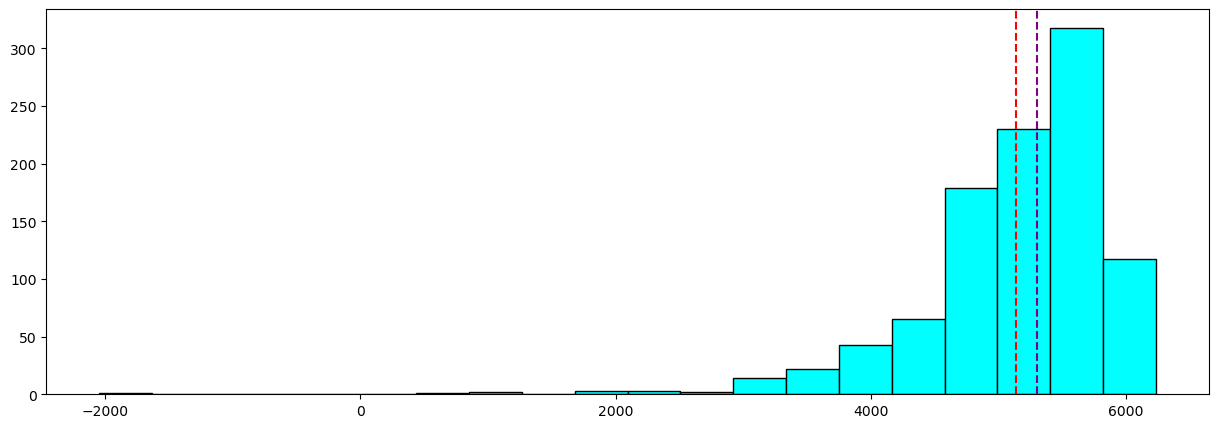

In [15]:
for team in numerical_values:
    plt.figure(figsize = (15,5))
    plt.hist(x = df_final[team], bins = 20, edgecolor = "black", label = f"{team}", color = 'cyan')
    plt.axvline(df_final[team].mean(), color = 'red', linestyle = "--")
    plt.axvline(df_final[team].median(), color = 'purple', linestyle = "--")
    plt.show()
